In [1]:
import pandas as pd

df = pd.read_csv("data/data.csv")

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (503, 34)

Column Names:
['Unnamed: 0', 'Punjab', 'Haryana', 'Rajasthan', 'Delhi', 'UP', 'Uttarakhand', 'HP', 'J&K', 'Chandigarh', 'Chhattisgarh', 'Gujarat', 'MP', 'Maharashtra', 'Goa', 'DNH', 'Andhra Pradesh', 'Telangana', 'Karnataka', 'Kerala', 'Tamil Nadu', 'Pondy', 'Bihar', 'Jharkhand', 'Odisha', 'West Bengal', 'Sikkim', 'Arunachal Pradesh', 'Assam', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Tripura']


In [2]:
print(df.head())

            Unnamed: 0  Punjab  Haryana  Rajasthan  Delhi     UP  Uttarakhand  \
0  02/01/2019 00:00:00   119.9    130.3      234.1   85.8  313.9         40.7   
1  03/01/2019 00:00:00   121.9    133.5      240.2   85.5  311.8         39.3   
2  04/01/2019 00:00:00   118.8    128.2      239.8   83.5  320.7         38.1   
3  05/01/2019 00:00:00   121.0    127.5      239.1   79.2  299.0         39.2   
4  06/01/2019 00:00:00   121.4    132.6      240.4   76.6  286.8         39.2   

     HP   J&K  Chandigarh  ...  Odisha  West Bengal  Sikkim  \
0  30.0  52.5         5.0  ...    70.2        108.2     2.0   
1  30.1  54.1         4.9  ...    67.9        110.2     1.9   
2  30.1  53.2         4.8  ...    66.3        106.8     1.7   
3  30.2  51.5         4.3  ...    65.8        107.0     2.0   
4  31.0  53.2         4.3  ...    62.9        106.4     2.0   

   Arunachal Pradesh  Assam  Manipur  Meghalaya  Mizoram  Nagaland  Tripura  
0                2.1   21.7      2.7        6.1      1.9

In [3]:
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         503 non-null    str    
 1   Punjab             503 non-null    float64
 2   Haryana            503 non-null    float64
 3   Rajasthan          503 non-null    float64
 4   Delhi              503 non-null    float64
 5   UP                 503 non-null    float64
 6   Uttarakhand        503 non-null    float64
 7   HP                 503 non-null    float64
 8   J&K                503 non-null    float64
 9   Chandigarh         503 non-null    float64
 10  Chhattisgarh       503 non-null    float64
 11  Gujarat            503 non-null    float64
 12  MP                 503 non-null    float64
 13  Maharashtra        503 non-null    float64
 14  Goa                503 non-null    float64
 15  DNH                503 non-null    float64
 16  Andhra Pradesh     503 non-null    fl

In [4]:
df = df.rename(columns={'Unnamed: 0': 'Date'})

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print(df.head())
print(df.dtypes)

        Date  Punjab  Haryana  Rajasthan  Delhi     UP  Uttarakhand    HP  \
0 2019-01-02   119.9    130.3      234.1   85.8  313.9         40.7  30.0   
1 2019-01-03   121.9    133.5      240.2   85.5  311.8         39.3  30.1   
2 2019-01-04   118.8    128.2      239.8   83.5  320.7         38.1  30.1   
3 2019-01-05   121.0    127.5      239.1   79.2  299.0         39.2  30.2   
4 2019-01-06   121.4    132.6      240.4   76.6  286.8         39.2  31.0   

    J&K  Chandigarh  ...  Odisha  West Bengal  Sikkim  Arunachal Pradesh  \
0  52.5         5.0  ...    70.2        108.2     2.0                2.1   
1  54.1         4.9  ...    67.9        110.2     1.9                2.2   
2  53.2         4.8  ...    66.3        106.8     1.7                2.2   
3  51.5         4.3  ...    65.8        107.0     2.0                2.2   
4  53.2         4.3  ...    62.9        106.4     2.0                2.2   

   Assam  Manipur  Meghalaya  Mizoram  Nagaland  Tripura  
0   21.7      2.7    

In [5]:
print("Starting Date:", df['Date'].min())
print("Ending Date:", df['Date'].max())

print("\nNumber of Records:", len(df))
print("Number of Days:", df['Date'].nunique())

Starting Date: 2019-01-02 00:00:00
Ending Date: 2020-12-05 00:00:00

Number of Records: 503
Number of Days: 498


In [6]:
print(df['Date'].is_monotonic_increasing)

True


In [7]:
duplicate_dates = df[df['Date'].duplicated(keep=False)]

print(duplicate_dates[['Date']].sort_values('Date'))

          Date
182 2019-07-08
183 2019-07-08
184 2019-07-09
185 2019-07-09
186 2019-07-10
187 2019-07-10
188 2019-07-11
189 2019-07-11
190 2019-07-12
191 2019-07-12


In [8]:
print("Number of duplicate rows:", df['Date'].duplicated().sum())

Number of duplicate rows: 5


In [9]:
print(df[df['Date'].duplicated(keep=False)].to_string(index=False))

      Date  Punjab  Haryana  Rajasthan  Delhi    UP  Uttarakhand   HP  J&K  Chandigarh  Chhattisgarh  Gujarat    MP  Maharashtra  Goa  DNH  Andhra Pradesh  Telangana  Karnataka  Kerala  Tamil Nadu  Pondy  Bihar  Jharkhand  Odisha  West Bengal  Sikkim  Arunachal Pradesh  Assam  Manipur  Meghalaya  Mizoram  Nagaland  Tripura
2019-07-08    77.9     86.6      171.8   57.8 280.3         21.6 12.1 46.6         2.5          76.5    261.3 179.6        380.5  7.8  2.7           168.7      143.8      196.4    69.6       253.7    5.4   80.8       24.4    69.7        118.8     1.0                1.4   15.8      2.5        4.0      1.4       2.0      3.3
2019-07-08    75.3     86.1      154.1   59.9 268.3         22.1 13.9 45.5         2.6          77.9    265.8 182.2        388.6  8.2  2.9           170.6      145.1      207.4    71.7       255.6    5.7   70.2       22.6    78.2        118.4     1.3                1.4   15.5      2.3        3.7      1.5       2.1      3.4
2019-07-09    68.5     84

In [10]:
print(df.describe())

                             Date      Punjab     Haryana   Rajasthan  \
count                         503  503.000000  503.000000  503.000000   
mean   2019-09-25 13:27:18.966202  141.145527  138.333598  218.443340   
min           2019-01-02 00:00:00   56.100000   64.800000  105.800000   
25%           2019-05-11 12:00:00  104.000000  114.800000  205.800000   
50%           2019-09-12 00:00:00  118.300000  126.800000  222.900000   
75%           2020-01-25 12:00:00  162.500000  158.100000  237.600000   
max           2020-12-05 00:00:00  300.000000  237.200000  278.000000   
std                           NaN   56.977361   38.106593   27.421615   

            Delhi          UP  Uttarakhand          HP         J&K  \
count  503.000000  503.000000   503.000000  503.000000  503.000000   
mean    83.380716  314.036382    36.157058   26.568191   44.264016   
min     41.800000  186.800000    16.800000   11.800000   17.800000   
25%     63.500000  263.650000    33.800000   25.600000   41.55

In [11]:
state_columns = df.columns.drop('Date')

state_averages = df[state_columns].mean().sort_values(ascending=False)

print("Top 10 States by Average Value:")
print(state_averages.head(10))

print("\nBottom 10 States by Average Value:")
print(state_averages.tail(10))

Top 10 States by Average Value:
Maharashtra       431.570179
Gujarat           323.039563
UP                314.036382
Tamil Nadu        300.738569
Rajasthan         218.443340
MP                208.283101
Karnataka         204.106759
Telangana         187.008549
Andhra Pradesh    176.151889
Punjab            141.145527
dtype: float64

Bottom 10 States by Average Value:
Goa                  11.093241
Pondy                 7.472962
Meghalaya             5.643738
Chandigarh            4.141551
Tripura               4.085487
Manipur               2.494632
Nagaland              2.162425
Arunachal Pradesh     2.109145
Mizoram               1.706362
Sikkim                1.289463
dtype: float64


In [12]:
df['Total'] = df[state_columns].sum(axis=1)

print("Average Total:", df['Total'].mean())
print("Peak Total:", df['Total'].max())
print("Minimum Total:", df['Total'].min())

Average Total: 3399.061431411531
Peak Total: 4059.1
Minimum Total: 2555.8


In [13]:
print(df[['Date', 'Total']].head())

        Date   Total
0 2019-01-02  3373.4
1 2019-01-03  3403.7
2 2019-01-04  3304.1
3 2019-01-05  3308.9
4 2019-01-06  3316.9


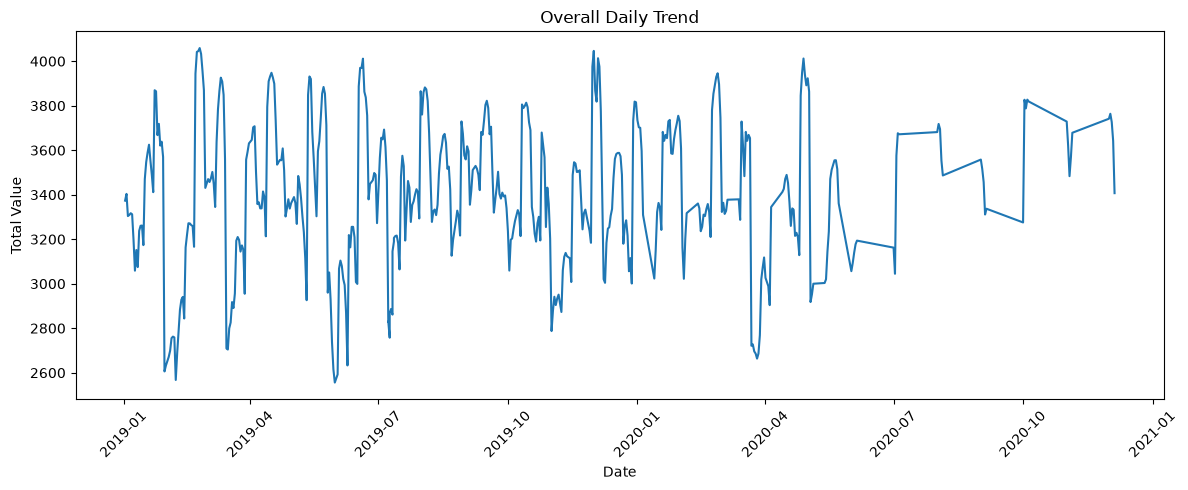

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(df['Date'], df['Total'])

plt.title('Overall Daily Trend')
plt.xlabel('Date')
plt.ylabel('Total Value')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

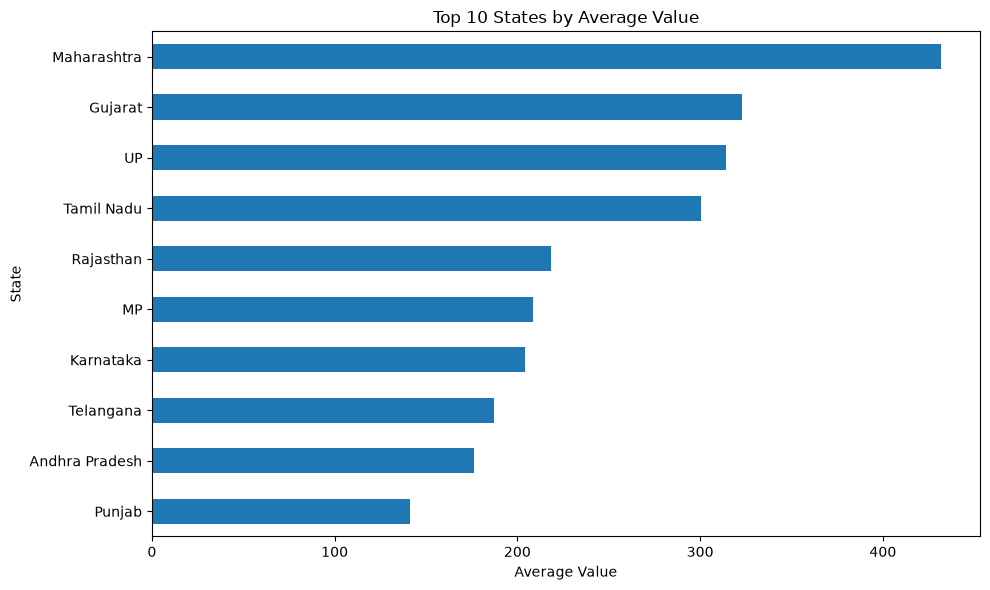

In [15]:
top10 = state_averages.head(10)

plt.figure(figsize=(10, 6))

top10.sort_values().plot(kind='barh')

plt.title('Top 10 States by Average Value')
plt.xlabel('Average Value')
plt.ylabel('State')

plt.tight_layout()
plt.show()

In [16]:
df['Year'] = df['Date'].dt.year

print("Available Years:")
print(sorted(df['Year'].unique()))

Available Years:
[np.int32(2019), np.int32(2020)]


In [17]:
states = sorted(state_columns.tolist())

print("Number of States:", len(states))
print("\nStates:")
print(states)

Number of States: 33

States:
['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'DNH', 'Delhi', 'Goa', 'Gujarat', 'HP', 'Haryana', 'J&K', 'Jharkhand', 'Karnataka', 'Kerala', 'MP', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Pondy', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'UP', 'Uttarakhand', 'West Bengal']


In [18]:
# Example: Maharashtra data for 2019

maharashtra_2019 = df[
    (df['Maharashtra'].notna()) &
    (df['Year'] == 2019)
]

print("Number of records:", len(maharashtra_2019))
print("\nFirst 5 records:")
print(maharashtra_2019[['Date', 'Maharashtra']].head())

Number of records: 359

First 5 records:
        Date  Maharashtra
0 2019-01-02        428.6
1 2019-01-03        419.6
2 2019-01-04        395.8
3 2019-01-05        411.1
4 2019-01-06        408.6


In [19]:
# Select a state
selected_state = 'Maharashtra'

# Calculate its average value
state_average = df[selected_state].mean()

print("Selected State:", selected_state)
print("Average Value:", round(state_average, 2))

Selected State: Maharashtra
Average Value: 431.57


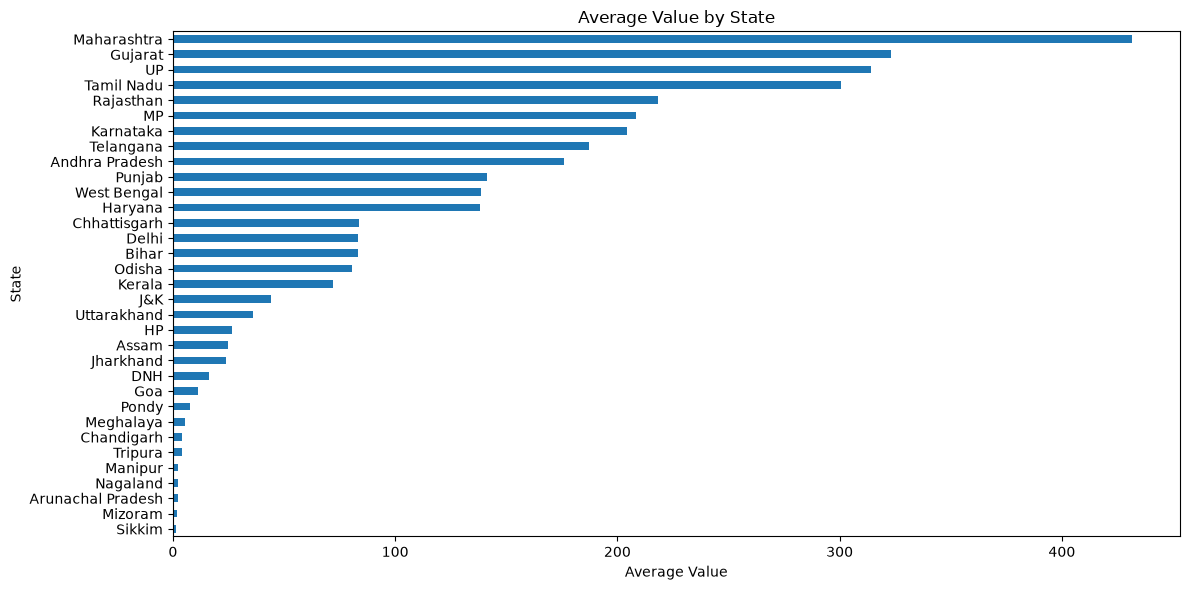

In [20]:
plt.figure(figsize=(12, 6))

state_averages.sort_values().plot(kind='barh')

plt.title('Average Value by State')
plt.xlabel('Average Value')
plt.ylabel('State')

plt.tight_layout()
plt.show()

In [21]:
df['Month'] = df['Date'].dt.month

print("Month values:")
print(sorted(df['Month'].unique()))

Month values:
[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]


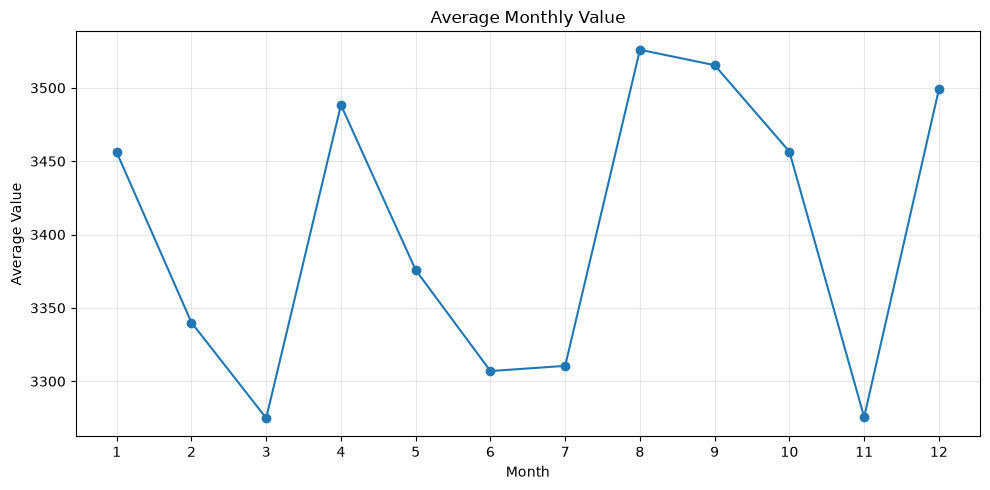

In [22]:
monthly_total = df.groupby('Month')['Total'].mean()

plt.figure(figsize=(10, 5))

plt.plot(monthly_total.index, monthly_total.values, marker='o')

plt.title('Average Monthly Value')
plt.xlabel('Month')
plt.ylabel('Average Value')

plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
df.to_csv("data/cleaned_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
